In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima import auto_arima


In [2]:
archivo = "../data/raw/report-ventas.csv"
df = pd.read_csv(archivo)
df

,activationTime,firstBillNumber,lastBillNumber,taxableBase,totalWithDiscount,discountsTotal,total,tip,tax 10%,tax 21%,card,cash,delitbee,gloriafood,glovo,justeat,shop,uber
0,03/01/2024,LS6700,LS6708,"183,80","225,97","23,79","202,18","0,00","18,38",NaN,"17,40","24,00",NaN,NaN,"22,39",NaN,NaN,"138,39"
1,04/01/2024,LS6709,LS6714,"120,71","141,67","8,89","132,78","1,00","12,07",NaN,"20,00",NaN,NaN,NaN,"27,99",NaN,"73,40","12,39"
2,05/01/2024,LS6715,LS6725,"278,51","315,26","8,89","306,37","0,00","27,86",NaN,"56,10","53,00",NaN,NaN,"51,88",NaN,"110,00","35,39"
3,06/01/2024,LS6726,LS6741,"351,62","439,90","52,94","386,96","1,07","34,98","0,36","155,96",NaN,NaN,NaN,NaN,NaN,"126,37","105,70"
4,07/01/2024,LS6742,LS6761,"405,97","565,24","117,57","447,67","1,05","39,56","2,14","52,20","56,20",NaN,NaN,"126,55",NaN,"83,45","130,32"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
613,06/12/2025,LS19037,LS19067,"974,22","1.078,60","6,27","1.072,33","2,80","96,84","1,27","296,10","112,70","20,00",NaN,"84,30","162,23",NaN,"399,80"
614,07/12/2025,LS19068,LS19078,"294,04","323,70","0,00","323,70","0,00","29,17","0,49","149,00","59,00","81,20",NaN,NaN,"34,50",NaN,NaN
615,09/12/2025,LS19079,LS19090,"227,31","256,60","6,57","250,03","0,00","22,72",NaN,"61,80","38,20","19,40",NaN,NaN,"88,33",NaN,"42,30"
616,10/12/2025,LS19091,LS19102,"254,26","296,50","16,80","279,70","0,00","25,44",NaN,"18,90","19,90","93,30",NaN,"80,80","28,50",NaN,"38,30"


In [3]:
df = df.iloc[:-1]

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   activationTime     617 non-null    object
 1   firstBillNumber    617 non-null    object
 2   lastBillNumber     617 non-null    object
 3   taxableBase        617 non-null    object
 4   totalWithDiscount  617 non-null    object
 5   discountsTotal     617 non-null    object
 6   total              617 non-null    object
 7   tip                617 non-null    object
 8   tax 10%            617 non-null    object
 9   tax 21%            293 non-null    object
 10  card               586 non-null    object
 11  cash               506 non-null    object
 12  delitbee           59 non-null     object
 13  gloriafood         402 non-null    object
 14  glovo              526 non-null    object
 15  justeat            397 non-null    object
 16  shop               113 non-null    object
 1

In [5]:
df["activationTime"] = pd.to_datetime(
    df["activationTime"],
    format="%d/%m/%Y"   # día/mes/año
)

df = df.sort_values("activationTime")

/tmp/ipykernel_913/3059042122.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["activationTime"] = pd.to_datetime(


In [6]:
df["total"] = (
    df["total"]
    .astype(str)
    .str.replace(".", "", regex=False)   # por si hubiera separador de miles
    .str.replace(",", ".", regex=False)  # coma -> punto decimal
    .astype(float)
)

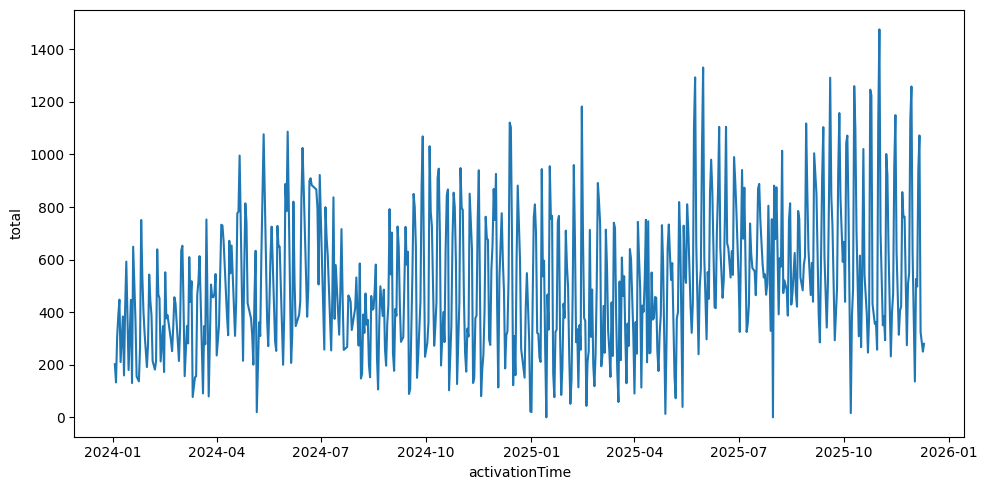

In [7]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data=df, x="activationTime", y="total")

plt.tight_layout()

plt.show()

In [8]:
df_copy = df[["activationTime", "total"]].copy()

In [9]:
df_copy

,activationTime,total
0,2024-01-03,202.18
1,2024-01-04,132.78
2,2024-01-05,306.37
3,2024-01-06,386.96
4,2024-01-07,447.67
...,...,...
612,2025-12-05,938.49
613,2025-12-06,1072.33
614,2025-12-07,323.70
615,2025-12-09,250.03


In [10]:
df_copy["activationTime"] = pd.to_datetime(df_copy["activationTime"], dayfirst=True)
# o si sabes el formato exacto:
# df["activationTime"] = pd.to_datetime(df["activationTime"], format="%d/%m/%Y")

# 2. Crear columna con día de la semana 1–7 (lunes=1, domingo=7)
df_copy["weekday_num"] = df_copy["activationTime"].dt.dayofweek + 1   # dayofweek: lunes=0 ... domingo=6
df_copy["weekday_num"] = df_copy["weekday_num"].astype("category")

In [11]:
df_copy
df_jueves = df_copy[df_copy["weekday_num"] == 4].copy()
df_jueves = df_copy[df_copy["weekday_num"] == 4].reset_index(drop=True)

In [12]:
df_jueves

,activationTime,total,weekday_num
0,2024-01-04,132.78,4
1,2024-01-11,159.38,4
2,2024-01-18,130.48,4
3,2024-01-25,266.66,4
4,2024-02-01,278.11,4
...,...,...,...
96,2025-11-06,293.39,4
97,2025-11-13,469.63,4
98,2025-11-20,422.59,4
99,2025-11-27,548.90,4


In [18]:
decomposition = seasonal_decompose(df_jueves["total"], period = 7)
decomposition

In [19]:
ts = df_jueves.set_index("activationTime")["total"].astype(float).to_numpy()   
tensor = ts.reshape(-1, 1)                                   
tensor.shape

(101, 1)

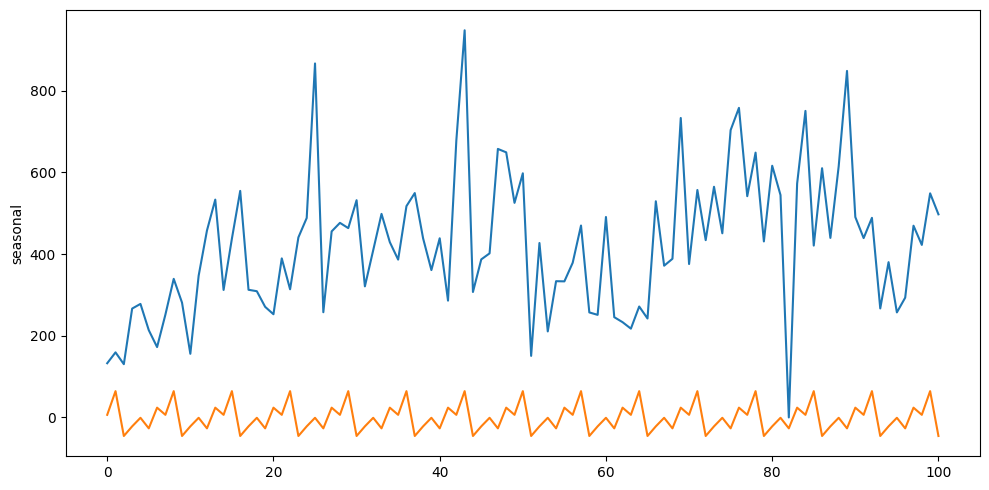

In [20]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

In [21]:
def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(ts)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -7.356981e+00
p-value                        9.722297e-11
#Lags Used                     0.000000e+00
Number of Observations Used    1.000000e+02
Critical Value (1%)           -3.497501e+00
Critical Value (5%)           -2.890906e+00
Critical Value (10%)          -2.582435e+00
dtype: float64

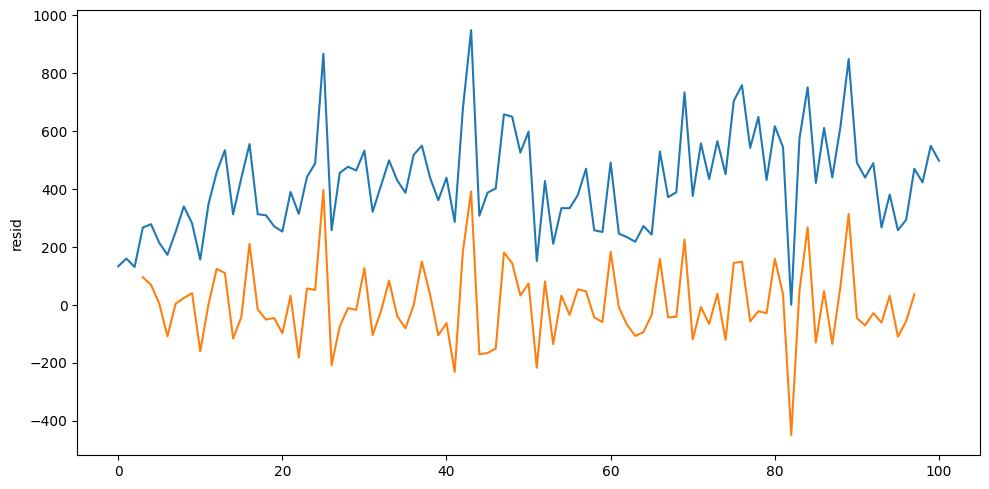

In [22]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

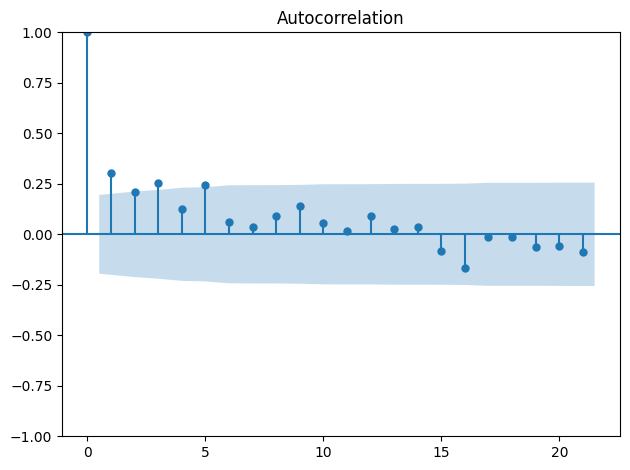

In [23]:
plot_acf(ts)

plt.tight_layout()

plt.show()

In [24]:
ts = df.set_index("activationTime")["total"].astype(float)
ts_stationary = ts.diff().dropna()

test_stationarity(ts_stationary)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -8.383687e+00
p-value                        2.470955e-13
#Lags Used                     1.700000e+01
Number of Observations Used    5.980000e+02
Critical Value (1%)           -3.441333e+00
Critical Value (5%)           -2.866385e+00
Critical Value (10%)          -2.569350e+00
dtype: float64

In [ ]:
model = auto_arima(ts_stationary, seasonal=True, m=7, trace=True)
model_sin_diff = auto_arima(ts, seasonal=True, m=7, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=8376.102, Time=2.03 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=8759.774, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=8717.560, Time=0.28 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=8527.522, Time=0.39 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=8757.774, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=8382.059, Time=1.02 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=8381.628, Time=1.08 sec
 ARIMA(2,0,2)(2,0,1)[7] intercept   : AIC=8381.350, Time=1.95 sec
 ARIMA(2,0,2)(1,0,2)[7] intercept   : AIC=8380.995, Time=2.18 sec
 ARIMA(2,0,2)(0,0,0)[7] intercept   : AIC=8381.586, Time=0.58 sec
 ARIMA(2,0,2)(0,0,2)[7] intercept   : AIC=8384.527, Time=1.99 sec
 ARIMA(2,0,2)(2,0,0)[7] intercept   : AIC=8380.297, Time=1.82 sec
 ARIMA(2,0,2)(2,0,2)[7] intercept   : AIC=8389.728, Time=2.40 sec
 ARIMA(1,0,2)(1,0,1)[7] intercept   : AIC=8470.957, Time=0.61 sec
 ARIMA(2,0,1)(1,0,1)[7] intercept